In [2]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [3]:
import os

for file in os.listdir("/"):
    if file.endswith(".zip"):
        print(file)

house-prices-advanced-regression-techniques.zip


In [4]:
import zipfile
import os

# Find the ZIP file automatically
zip_file = [f for f in os.listdir("/") if f.endswith(".zip")][0]

print("ZIP file found:", zip_file)

# Extract it
with zipfile.ZipFile("/" + zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/house_price_data")

print("Dataset extracted successfully!")
print(os.listdir("/content/house_price_data"))

ZIP file found: house-prices-advanced-regression-techniques.zip
Dataset extracted successfully!
['sample_submission.csv', 'train.csv', 'data_description.txt', 'test.csv']


In [5]:
import pandas as pd

# Load the training dataset
file_path = "/content/house_price_data/train.csv"

df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# Display dataset information
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1460, 81)

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPo

In [7]:
# Select required features
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]

X = df[features]
y = df["SalePrice"]

print("Input features:")
print(X.head())

print("\nTarget (House Price):")
print(y.head())

Input features:
   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2

Target (House Price):
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [8]:
print("Missing values in selected features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in selected features:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64

Missing values in target:
0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 3)
Testing data: (292, 3)


In [10]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [11]:
# Predict house prices for the test data
y_pred = model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 35788.061292436294
MSE : 2806426667.247853
RMSE: 52975.71771338122
R²  : 0.6341189942328371


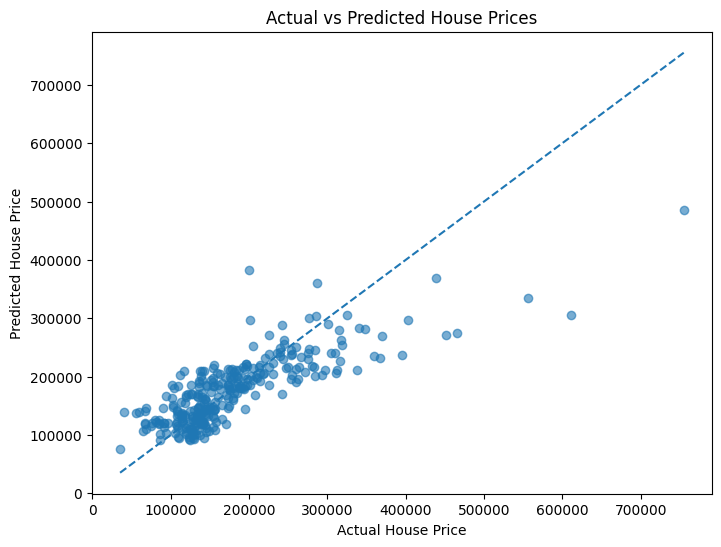

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [14]:
print("Linear Regression Coefficients")

for feature, coefficient in zip(features, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print(f"\nIntercept: {model.intercept_:.2f}")

Linear Regression Coefficients
GrLivArea: 104.03
BedroomAbvGr: -26655.17
FullBath: 30014.32

Intercept: 52261.75


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 35788.061292436294
MSE : 2806426667.247853
RMSE: 52975.71771338122
R²  : 0.6341189942328371
